In [5]:
from stlrom import *

driver = STLDriver()
driver.parse_string("signal x, y")
driver.parse_string("mux := x[t] > 0")
driver.parse_string("muy := y[t] > 0")
driver.parse_string("phi := mux and muy")
driver.parse_string("until_phi := mux until_[0, 1] muy")
driver.parse_string("ev_phi := ev_[0, 1] phi")

print(driver)


# STLDriver object defined as
signal x, y

# With formulas
ev_phi:= ev_[0,1] (x[t] > 0 and y[t] > 0) 
mux:= x[t] > 0
muy:= y[t] > 0
phi:= x[t] > 0 and y[t] > 0
until_phi:=  (x[t] > 0) until_[0,1] (y[t] > 0) 

# Data:
No data yet.


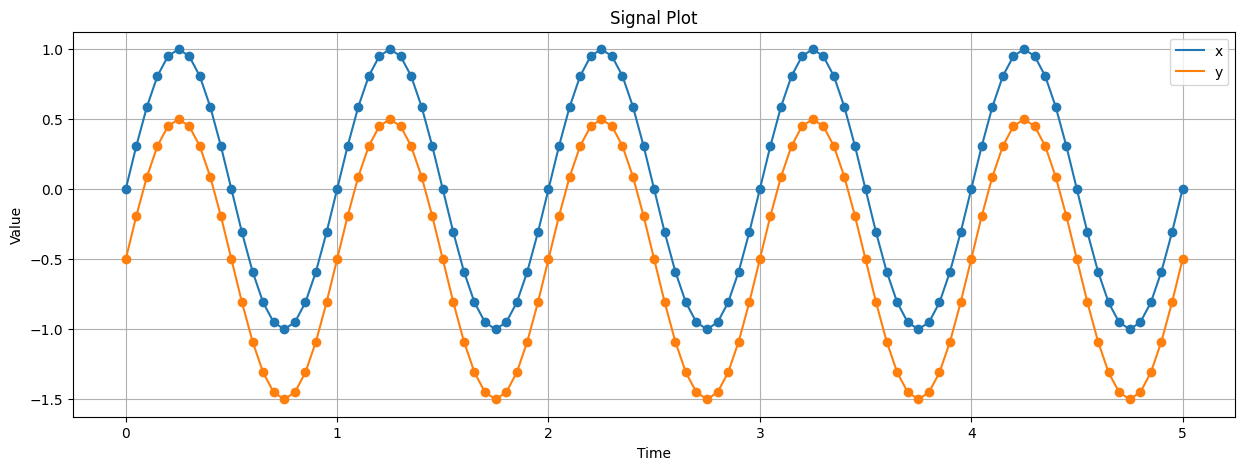

In [6]:
x_signal = OscillSignalGen().get_signal(t0=0, tf=5, dt=0.05)
y_signal = OscillSignalGen(base=-0.5).get_signal(t0=0, tf=5, dt=0.05)

ax = x_signal.plot(label='x')
ax = y_signal.plot(ax=ax, label='y')

driver.set_signals([x_signal, y_signal])

<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

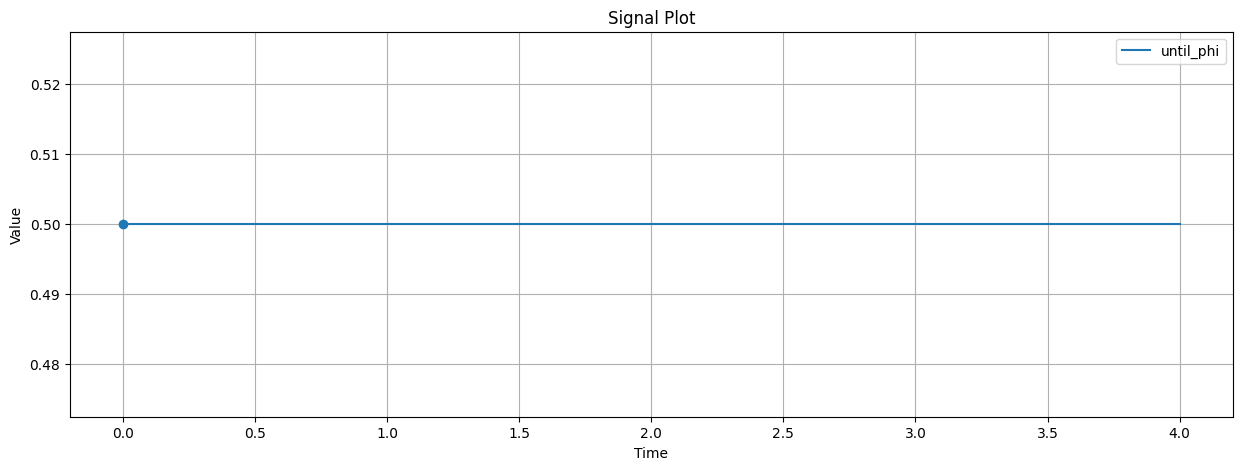

In [ ]:
z_ev = driver.eval_rob("ev_phi", 0, 4)
z_ev.plot(label='ev_phi')

In [8]:
rob_map = driver.get_robustness_map("ev_phi")

plot_rob_map_widget(rob_map)

interactive(children=(Dropdown(description='Subformula:', layout=Layout(width='22.5em'), options=('ev_[0,1] (x…